# 2.3.4 — Cosine similarity: the benchmarks

Measurements on the Cloud Veneto cluster (5 × `cloudveneto.large`: 1 scheduler + 4 workers with 4 vCPU and 8 GB each), 100,000 titles, September 2026.

| file in `results/` | what it is |
|---|---|
| `bench_cosine.csv` | the 12 September campaign, 85 measurements |
| `night_scatter_partitions.csv`, `night_scatter_workers.csv`, `night_scatter_8workers.csv` | the 13 September night run: the same point measured three times in a row inside one cluster (`--ripeti-punto 3`) |
| `night_node_1.csv` … `night_node_4.csv` | the same single-worker point on each of the four machines, 8 measurements × 5 clusters |
| `most_similar.csv`, `most_dissimilar.csv`, `histogram.csv` | the delivered result: top 20, bottom 20, and the distribution over 100 bins |
| `filters/*/` | the five filter configurations of the night run, with `--top 5000` |

`bench_cosine.csv` is **three appended invocations**, in this order, and no column tells them apart — only their position does: **7 rows** of calibration (including the two configurations that blow up, `k=8` and `k=4`), **72 rows** of the campaign (6 full passes), **6 rows** of the 8-worker run.

The CSVs keep the Italian column names written by `bench_cosine.py`:

| column | meaning |
|---|---|
| `curva` | which curve the measurement belongs to: `partizioni` (block sweep), `worker`, `thread`, `numpy` (single-core baseline) |
| `valore` | the value of that curve's independent variable |
| `ripetizione` | which full pass of the campaign, each one on a brand new cluster |
| `misura` | night files only: `0` is the first time that point runs in that cluster, `>0` the ones after it |
| `secondi` | wall-clock seconds, empty when the run did not complete |
| `errore` | the exception, when the run did not complete |
| `titoli`, `partizioni`, `worker`, `thread` | state of the run |

**One reading rule that changes the numbers.** The reference point — 4 workers × 4 threads, `k=32` — is measured by all three curves, and the `curva=worker` one is 17% faster than the `curva=partizioni` one (17.41 s against 20.98 s, 10.5 σ) because it ran 5th in its cluster: see `README.md`, *Il difetto che questa campagna ha trovato in sé stessa*. Every plot here uses the partition-sweep value, **20.98 s**, so the worker speedup is 3.66× and not 4.41×.

The NumPy baseline is every single-core measurement in the file, the calibration and the 8-worker run included.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
})
BLUE, ORANGE, GREEN, PURPLE, RED, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#805ad5", "#c53030", "#8a8a8a"

def label(workers, threads):
    return f"{workers} worker{'s' * (workers > 1)} × {threads} thread{'s' * (threads > 1)}"

BASE = Path("nicco_scripts/results") if Path("nicco_scripts/results").is_dir() else Path("results")
bench = pd.read_csv(BASE / "bench_cosine.csv")
bench["block"] = ["calibration"] * 7 + ["campaign"] * 72 + ["8 workers"] * 6

calibration = bench[bench.block == "calibration"]
campaign = bench[bench.block == "campaign"]
eight = bench[bench.block == "8 workers"]
numpy_seconds = bench[bench.curva == "numpy"].secondi.mean()

def stats(table, curve, value):
    seconds = table[(table.curva == curve) & (table.valore == value)].secondi
    return seconds.mean(), seconds.std()

reference = stats(campaign, "partizioni", 32)

(bench.groupby(["block", "curva"], sort=False)
      .agg(measurements=("secondi", "size"), completed=("secondi", "count")))

measurements  completed
block       curva                              
calibration numpy                  1          1
            partizioni             6          4
campaign    numpy                  6          6
            partizioni            24         24
            worker                24         24
            thread                18         18
8 workers   numpy                  3          3
            worker                 3          3

## Runtime vs number of blocks

The block count `k` splits the title matrix into `k × k` tiles. Measured on 100,000 titles, 6 passes. The crosses are the two configurations that did not complete, both from the calibration: `k=8` died with `KilledWorker`, `k=4` on a cluster that had not recovered from it yet.

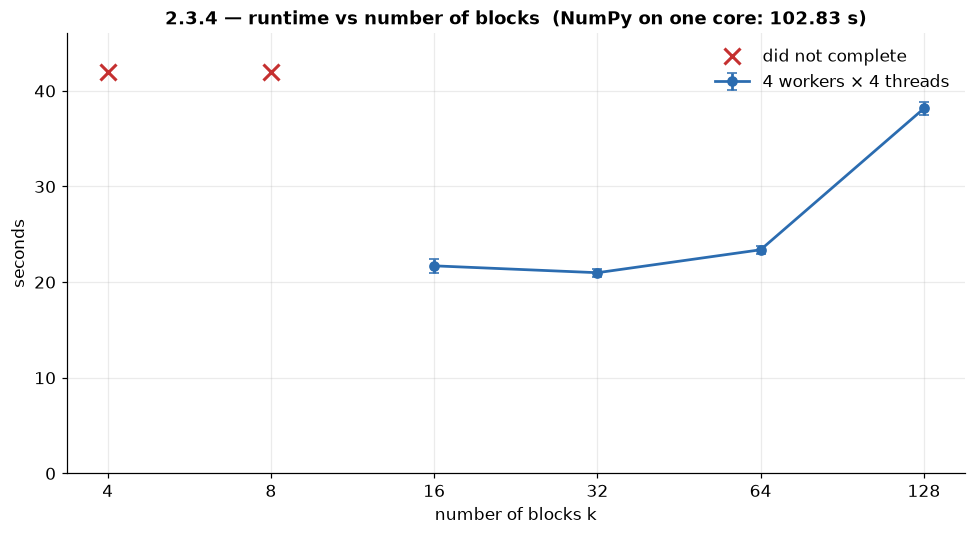

In [2]:
curve = campaign[campaign.curva == "partizioni"].groupby("valore").secondi.agg(["mean", "std"])
failures = sorted(calibration[calibration.secondi.isna()].valore)
blocks = sorted(set(curve.index) | set(failures))

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", ms=6, lw=1.8,
            capsize=3, color=BLUE, label=label(4, 4))
ax.plot(failures, [42] * len(failures), "x", ms=10, mew=2, color=RED,
        label="did not complete")

ax.set_xscale("log", base=2)
ax.set_xticks(blocks)
ax.set_xticklabels(blocks)
ax.set_ylim(0, 46)
ax.set_xlabel("number of blocks k")
ax.set_ylabel("seconds")
ax.set_title(f"2.3.4 — runtime vs number of blocks  (NumPy on one core: {numpy_seconds:.2f} s)")
ax.legend()
fig.tight_layout()

## Runtime vs number of workers

Measured at `k=32`, with 4 threads per worker, one worker per machine. On the right, the speedup over a single worker against the ideal line.

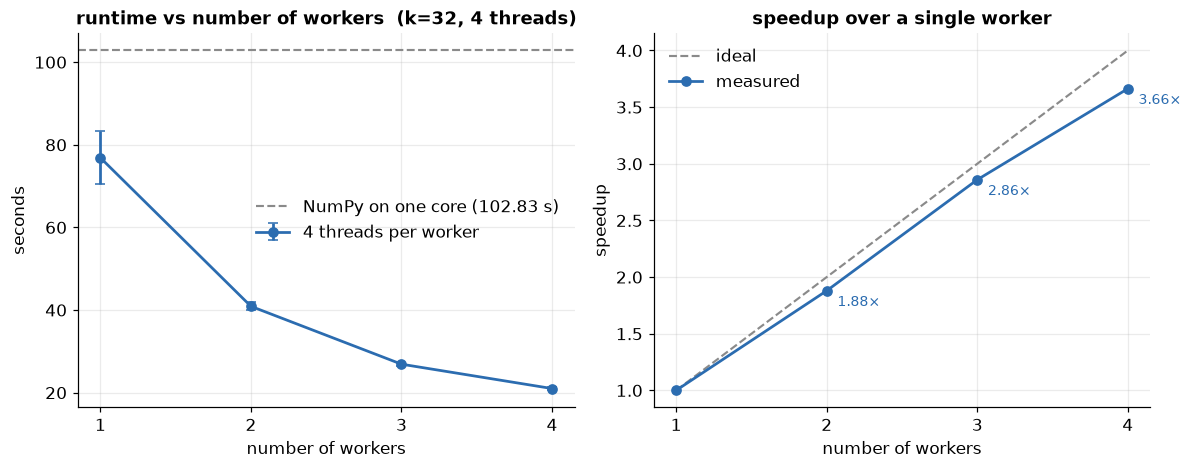

In [3]:
workers = campaign[campaign.curva == "worker"].groupby("valore").secondi.agg(["mean", "std"])
workers.loc[4] = reference
workers = workers.sort_index()
speedup = workers["mean"].iloc[0] / workers["mean"]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.4))

left.errorbar(workers.index, workers["mean"], yerr=workers["std"], marker="o", ms=6,
              lw=1.8, capsize=3, color=BLUE, label="4 threads per worker")
left.axhline(numpy_seconds, ls="--", lw=1.4, color=GREY,
             label=f"NumPy on one core ({numpy_seconds:.2f} s)")
left.set_xticks(workers.index)
left.set_xlabel("number of workers")
left.set_ylabel("seconds")
left.set_title("runtime vs number of workers  (k=32, 4 threads)")
left.legend()

right.plot(workers.index, workers.index, ls="--", lw=1.4, color=GREY, label="ideal")
right.plot(workers.index, speedup, marker="o", ms=6, lw=1.8, color=BLUE, label="measured")
for count, value in speedup.items():
    if count > 1:
        right.annotate(f"{value:.2f}×", (count, value), textcoords="offset points",
                       xytext=(7, -10), fontsize=9, color=BLUE)
right.set_xticks(workers.index)
right.set_xlabel("number of workers")
right.set_ylabel("speedup")
right.set_title("speedup over a single worker")
right.legend()
fig.tight_layout()

## The whole picture: every configuration measured

The seven configurations, ordered by the cluster cores they occupy. The `8 workers × 1 thread` point is the only one where two workers share a machine, and it is the clean processes-against-threads comparison: same 8 cores, same 4 machines, as `4 workers × 2 threads`.

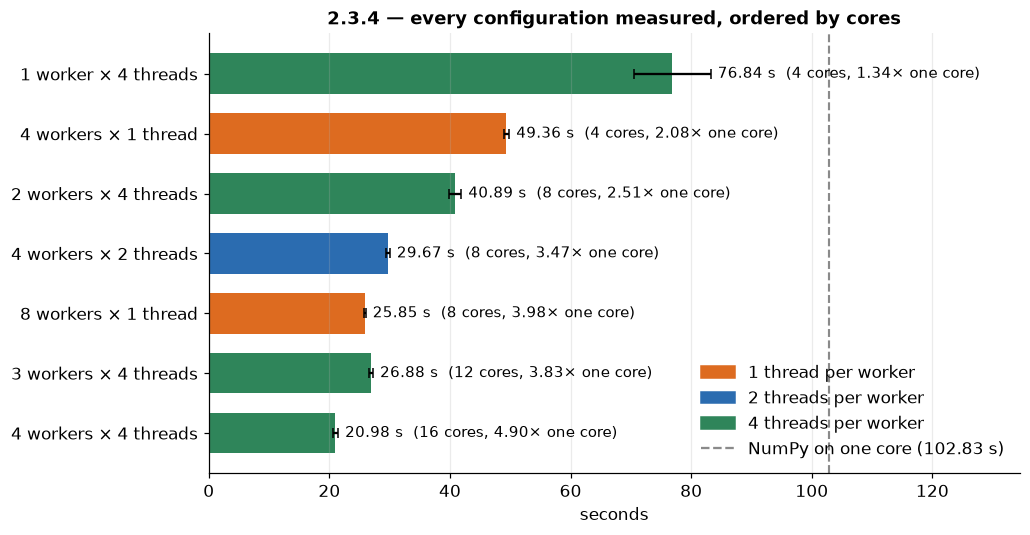

In [4]:
COLOR_BY_THREADS = {1: ORANGE, 2: BLUE, 4: GREEN}
configurations = [(1, 4, *stats(campaign, "worker", 1)),
                  (4, 1, *stats(campaign, "thread", 1)),
                  (2, 4, *stats(campaign, "worker", 2)),
                  (4, 2, *stats(campaign, "thread", 2)),
                  (8, 1, *stats(eight, "worker", 8)),
                  (3, 4, *stats(campaign, "worker", 3)),
                  (4, 4, *reference)]

names = [label(w, t) for w, t, _, _ in configurations]
seconds = [s for _, _, s, _ in configurations]
deviations = [sd for _, _, _, sd in configurations]
cores = [w * t for w, t, _, _ in configurations]
colors = [COLOR_BY_THREADS[t] for _, t, _, _ in configurations]

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.barh(names, seconds, xerr=deviations, color=colors, height=0.68, capsize=3)
for bar, value, sd, n in zip(bars, seconds, deviations, cores):
    ax.text(value + sd + 1.2, bar.get_y() + bar.get_height() / 2,
            f"{value:.2f} s  ({n} cores, {numpy_seconds / value:.2f}× one core)",
            va="center", fontsize=10)

ax.axvline(numpy_seconds, ls="--", lw=1.4, color=GREY)
ax.legend(handles=[Patch(color=COLOR_BY_THREADS[t], label=f"{t} thread{'s' * (t > 1)} per worker")
                   for t in (1, 2, 4)]
                  + [Line2D([], [], ls="--", color=GREY,
                            label=f"NumPy on one core ({numpy_seconds:.2f} s)")],
          loc="lower right")
ax.invert_yaxis()
ax.set_xlim(0, max(seconds) * 1.75)
ax.set_xlabel("seconds")
ax.set_title("2.3.4 — every configuration measured, ordered by cores")
ax.grid(axis="y", visible=False)
fig.tight_layout()

## The night run: does distributing the data cost anything?

`--ripeti-punto 3` runs the same point three times in a row inside one cluster: the first run (`misura=0`) pays for the `scatter` of the blocks, the others find them already on the workers.

On the left, the first run against the later ones for each `k`. On the right, first minus later for each worker count: each bar is the mean over the campaign passes, the error bar their standard deviation.

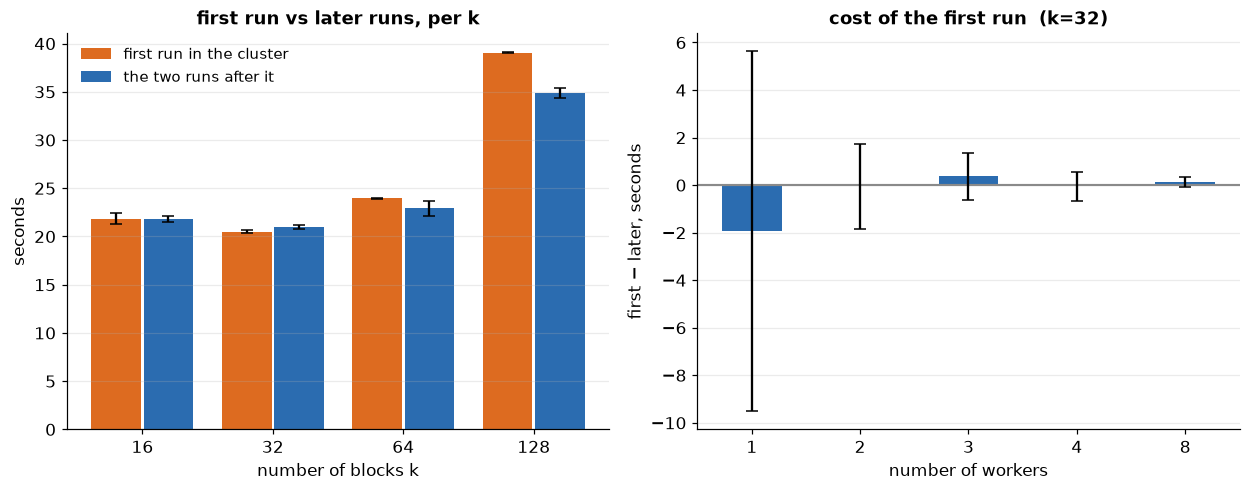

In [5]:
by_k = pd.read_csv(BASE / "night_scatter_partitions.csv")
by_workers = pd.concat([pd.read_csv(BASE / "night_scatter_workers.csv"),
                        pd.read_csv(BASE / "night_scatter_8workers.csv")])

def cold_minus_warm(table):
    rows = []
    for (value, repetition), group in table.groupby(["valore", "ripetizione"]):
        rows.append({"valore": value,
                     "difference": (group.loc[group.misura == 0, "secondi"].mean()
                                    - group.loc[group.misura > 0, "secondi"].mean())})
    return pd.DataFrame(rows).groupby("valore").difference.agg(["mean", "std"])

cold = by_k[by_k.misura == 0].groupby("valore").secondi.agg(["mean", "std"])
warm = by_k[by_k.misura > 0].groupby("valore").secondi.agg(["mean", "std"])
difference = cold_minus_warm(by_workers)

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.6))

position = np.arange(len(cold))
left.bar(position - 0.2, cold["mean"], yerr=cold["std"], width=0.38, color=ORANGE,
         capsize=4, label="first run in the cluster")
left.bar(position + 0.2, warm["mean"], yerr=warm["std"], width=0.38, color=BLUE,
         capsize=4, label="the two runs after it")
left.set_xticks(position)
left.set_xticklabels(cold.index)
left.set_xlabel("number of blocks k")
left.set_ylabel("seconds")
left.set_title("first run vs later runs, per k")
left.legend(fontsize=10)
left.grid(axis="x", visible=False)

right.axhline(0, lw=1.4, color=GREY)
right.bar([str(n) for n in difference.index], difference["mean"], yerr=difference["std"],
          width=0.55, color=BLUE, capsize=4)
right.set_xlabel("number of workers")
right.set_ylabel("first − later, seconds")
right.set_title("cost of the first run  (k=32)")
right.grid(axis="x", visible=False)
fig.tight_layout()

## The night run: one worker is the noisy configuration

The same single-worker point, `k=32`, run on each of the four machines: 8 measurements inside a standing cluster, repeated on 5 clusters. On the right, the dispersion inside one standing cluster against the dispersion between clusters — if it were the cluster startup, the second one would be the larger.

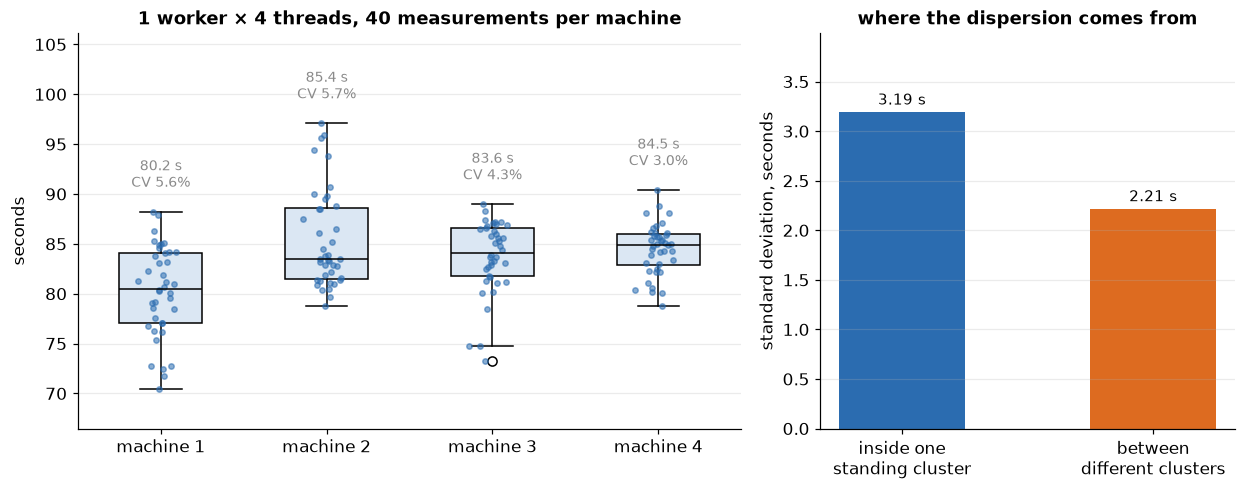

In [6]:
nodes = pd.concat([pd.read_csv(BASE / f"night_node_{n}.csv").assign(node=n) for n in (1, 2, 3, 4)])
grouped = [nodes[nodes.node == n].secondi.values for n in (1, 2, 3, 4)]
within = nodes.groupby(["node", "ripetizione"]).secondi.std().mean()
between = nodes.groupby(["node", "ripetizione"]).secondi.mean().groupby("node").std().mean()

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                                  gridspec_kw={"width_ratios": [1.6, 1]})

box = left.boxplot(grouped, tick_labels=[f"machine {n}" for n in (1, 2, 3, 4)],
                   widths=0.5, patch_artist=True, medianprops={"color": "black"})
for patch in box["boxes"]:
    patch.set_facecolor("#dbe7f3")
for position, values in enumerate(grouped, start=1):
    jitter = np.random.default_rng(0).normal(0, 0.06, len(values))
    left.plot(position + jitter, values, "o", ms=3.5, color=BLUE, alpha=0.55)
for position, values in enumerate(grouped, start=1):
    left.text(position, values.max() + 2.5,
              f"{values.mean():.1f} s\nCV {100 * values.std() / values.mean():.1f}%",
              ha="center", fontsize=9, color=GREY)
left.set_ylabel("seconds")
left.set_ylim(min(v.min() for v in grouped) - 4, max(v.max() for v in grouped) + 9)
left.set_title("1 worker × 4 threads, 40 measurements per machine")
left.grid(axis="x", visible=False)

bars = right.bar(["inside one\nstanding cluster", "between\ndifferent clusters"],
                 [within, between], width=0.5, color=[BLUE, ORANGE])
for bar, value in zip(bars, [within, between]):
    right.text(bar.get_x() + bar.get_width() / 2, value + 0.08, f"{value:.2f} s",
               ha="center", fontsize=10)
right.set_ylabel("standard deviation, seconds")
right.set_ylim(0, max(within, between) * 1.25)
right.set_title("where the dispersion comes from")
right.grid(axis="x", visible=False)
fig.tight_layout()

## The result: the distribution of the similarities

All 4,999,950,000 pairs of the 100,000 titles, in the 100 bins of `histogram.csv`, on a logarithmic count axis. The bins run over the whole theoretical range `[-1, 1]`.

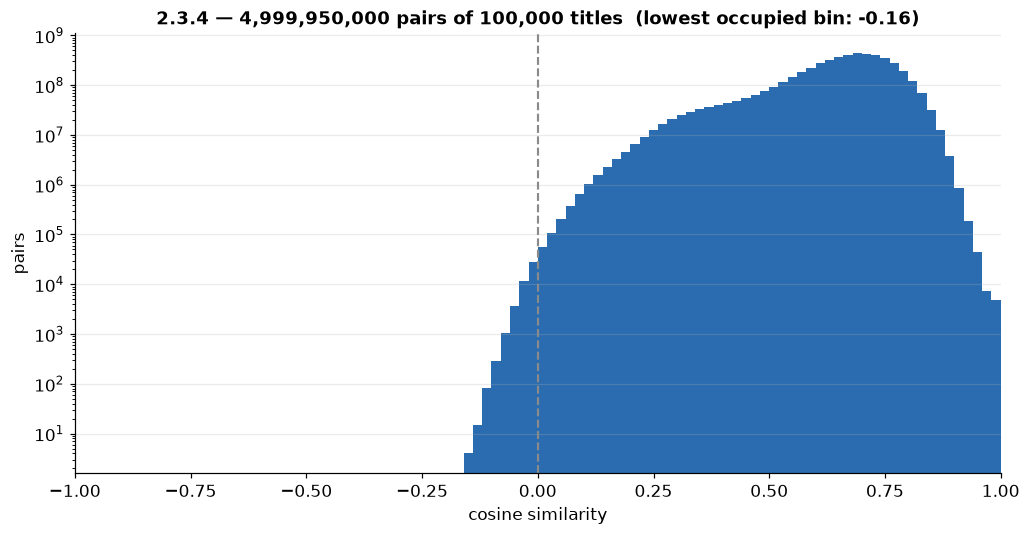

In [7]:
counts = np.loadtxt(BASE / "histogram.csv", dtype=np.int64)
edges = np.linspace(-1.0, 1.0, len(counts) + 1)
centres = (edges[:-1] + edges[1:]) / 2
occupied = np.nonzero(counts)[0]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.bar(centres, counts, width=edges[1] - edges[0], color=BLUE, align="center")
ax.axvline(0, lw=1.4, ls="--", color=GREY)
ax.set_yscale("log")
ax.set_xlim(-1, 1)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("pairs")
ax.set_title(f"2.3.4 — {counts.sum():,} pairs of 100,000 titles"
             f"  (lowest occupied bin: {edges[occupied[0]]:.2f})")
ax.grid(axis="x", visible=False)
fig.tight_layout()